<a href="https://colab.research.google.com/github/bahawal-khan/DeepLearning-practice/blob/main/CNN/Data_Augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Without Data Augmentation Model Accuracy**


In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100% 1.06G/1.06G [00:10<00:00, 112MB/s]



In [5]:
!unzip -q dogsvscats.zip -d dataset

In [6]:
import os

for root, dirs, files in os.walk("dataset"):
    print(root)

dataset
dataset/catsvsdogs
dataset/catsvsdogs/test
dataset/catsvsdogs/test/cats
dataset/catsvsdogs/test/dogs
dataset/catsvsdogs/train
dataset/catsvsdogs/train/cats
dataset/catsvsdogs/train/dogs
dataset/test
dataset/test/cats
dataset/test/dogs
dataset/train
dataset/train/cats
dataset/train/dogs


In [7]:
import os

print("Train Cats:", len(os.listdir("dataset/train/cats")))
print("Train Dogs:", len(os.listdir("dataset/train/dogs")))

print("Test Cats:", len(os.listdir("dataset/test/cats")))
print("Test Dogs:", len(os.listdir("dataset/test/dogs")))

Train Cats: 10000
Train Dogs: 10000
Test Cats: 2500
Test Dogs: 2500


In [8]:
import tensorflow as tf

train_dataset = tf.keras.utils.image_dataset_from_directory(
    "dataset/train",
    image_size=(256, 256),
    batch_size=32,
    shuffle=True
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    "dataset/test",
    image_size=(256, 256),
    batch_size=32,
    shuffle=False
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [9]:
print(train_dataset.class_names)

['cats', 'dogs']


In [10]:
for images, labels in train_dataset.take(1):
    print(images.shape)
    print(labels.shape)

(32, 256, 256, 3)
(32,)


In [11]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [12]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "dataset/train",
    image_size=(256,256),
    batch_size=32,
    shuffle=True
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    "dataset/test",
    image_size=(256,256),
    batch_size=32,
    shuffle=False
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


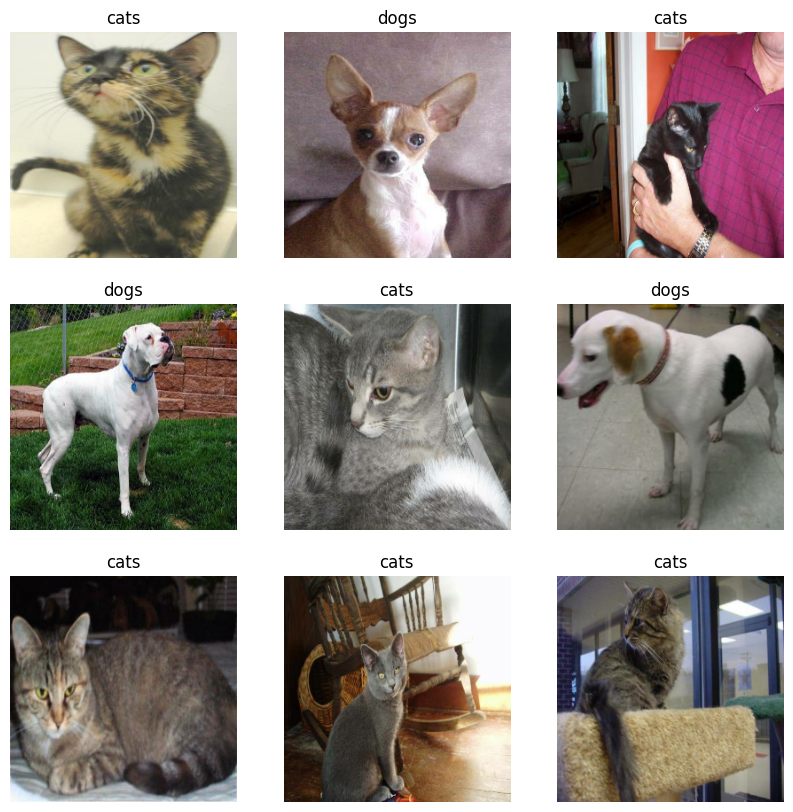

In [13]:
plt.figure(figsize=(10,10))

for images,labels in train_dataset.take(1):

    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_dataset.class_names[labels[i]])
        plt.axis("off")

plt.show()

In [14]:
def process(image,label):

    image = tf.cast(image/255.0,tf.float32)

    return image,label

In [15]:
train_ds = train_dataset.map(process)
validation_ds = validation_dataset.map(process)

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,BatchNormalization

In [17]:
model = Sequential()

model.add(Conv2D(32,(3,3),padding="valid",activation="relu",input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),padding="valid",activation="relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128,(3,3),padding="valid",activation="relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128,activation="relu"))
model.add(Dense(64,activation="relu"))

model.add(Dense(1,activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [20]:
history_without = model.fit(
    train_ds,
    epochs=10,
    validation_data=validation_ds
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 69s 92ms/step - accuracy: 0.6827 - loss: 0.7813 - val_accuracy: 0.6892 - val_loss: 0.6115
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.7967 - loss: 0.4386 - val_accuracy: 0.7180 - val_loss: 0.5883
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.8448 - loss: 0.3525 - val_accuracy: 0.7530 - val_loss: 0.6099
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.8871 - loss: 0.2734 - val_accuracy: 0.7828 - val_loss: 0.6749
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.9302 - loss: 0.1783 - val_accuracy: 0.8078 - val_loss: 0.6237
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.9618 - loss: 0.1051 - val_accuracy: 0.7956 - val_loss: 0.6304
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.9769 - loss: 0.0673 - val_accuracy: 0.8070 - val_loss: 0.7272
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.9836 - loss: 0.0461 - 

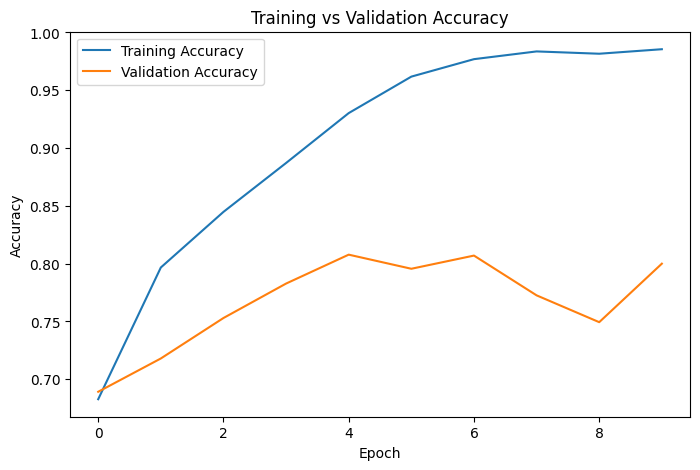

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_without.history['accuracy'], label='Training Accuracy')
plt.plot(history_without.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

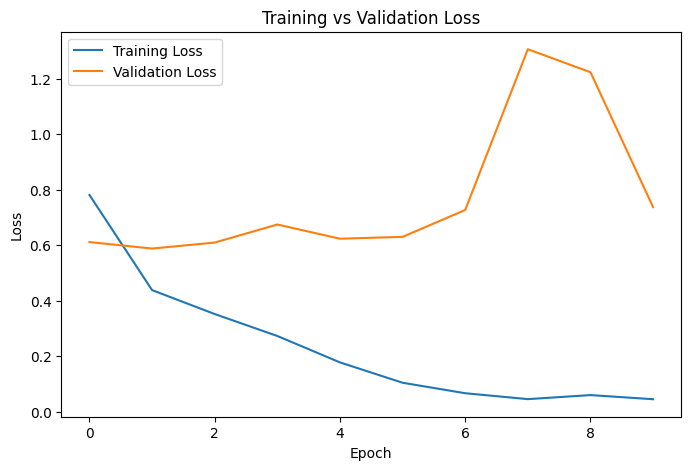

In [29]:
plt.figure(figsize=(8,5))

plt.plot(history_without.history['loss'], label='Training Loss')
plt.plot(history_without.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

**Overfitting During Training Now Apply Data Augmentation**

Data Augmentation is the process of creating different versions of training images using random transformations without changing their labels, so the model learns better and avoids overfitting.

In [21]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.2),

    tf.keras.layers.RandomZoom(0.2),

    tf.keras.layers.RandomContrast(0.2)

])

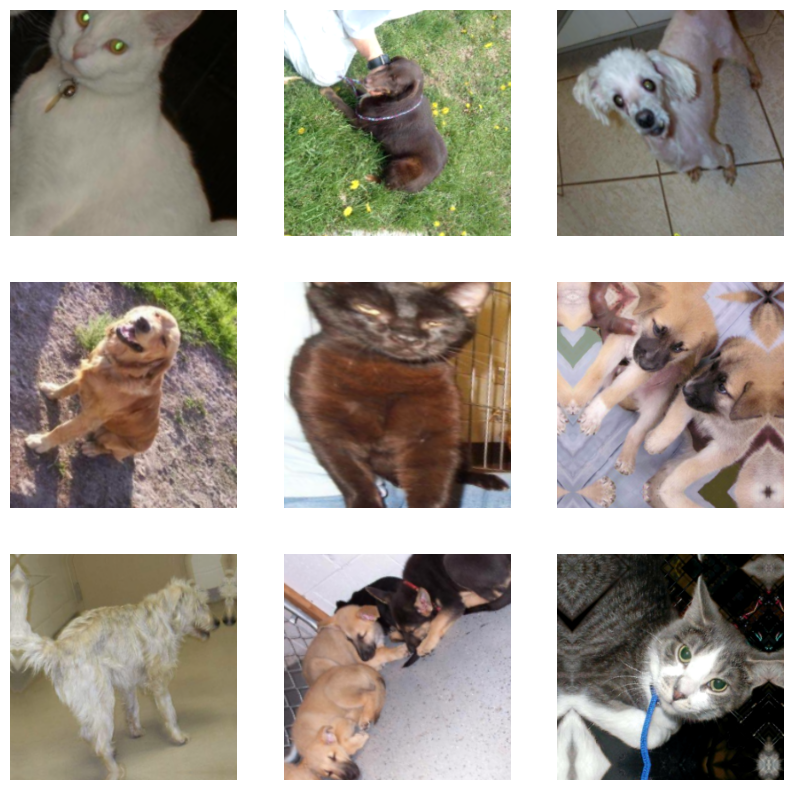

In [22]:
plt.figure(figsize=(10,10))

for images,labels in train_dataset.take(1):

    augmented_images = data_augmentation(images)

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(augmented_images[i].numpy().astype("uint8"))

        plt.axis("off")

plt.show()

In [23]:
train_ds_aug = train_ds.map(
    lambda x,y:(data_augmentation(x,training=True),y)
)

In [24]:
model2 = Sequential()

model2.add(Conv2D(32,(3,3),activation="relu",input_shape=(256,256,3)))
model2.add(BatchNormalization())
model2.add(MaxPooling2D())

model2.add(Conv2D(64,(3,3),activation="relu"))
model2.add(BatchNormalization())
model2.add(MaxPooling2D())

model2.add(Conv2D(128,(3,3),activation="relu"))
model2.add(BatchNormalization())
model2.add(MaxPooling2D())

model2.add(Flatten())

model2.add(Dense(128,activation="relu"))
model2.add(Dense(64,activation="relu"))

model2.add(Dense(1,activation="sigmoid"))

In [25]:
model2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [26]:
history_with = model2.fit(

    train_ds_aug,

    epochs=10,

    validation_data=validation_ds

)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 375s 591ms/step - accuracy: 0.5781 - loss: 1.2920 - val_accuracy: 0.6266 - val_loss: 0.6981
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 367s 587ms/step - accuracy: 0.6489 - loss: 0.6378 - val_accuracy: 0.6848 - val_loss: 0.5994
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 364s 581ms/step - accuracy: 0.6849 - loss: 0.5978 - val_accuracy: 0.6888 - val_loss: 0.6301
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 369s 590ms/step - accuracy: 0.7012 - loss: 0.5708 - val_accuracy: 0.7408 - val_loss: 0.5282
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 364s 581ms/step - accuracy: 0.7195 - loss: 0.5442 - val_accuracy: 0.7120 - val_loss: 0.5568
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 366s 585ms/step - accuracy: 0.7388 - loss: 0.5216 - val_accuracy: 0.7160 - val_loss: 0.6120
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 371s 594ms/step - accuracy: 0.7553 - loss: 0.5002 - val_accuracy: 0.7216 - val_loss: 0.5730
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 362s 579ms/step - accuracy: 0.7692 -

In [30]:
print("Without Data Augmentation")
print("Train Accuracy :",history_without.history["accuracy"][-1])
print("Validation Accuracy :",history_without.history["val_accuracy"][-1])

print()

print("With Data Augmentation")
print("Train Accuracy :",history_with.history["accuracy"][-1])
print("Validation Accuracy :",history_with.history["val_accuracy"][-1])

Without Data Augmentation
Train Accuracy : 0.9854999780654907
Validation Accuracy : 0.800000011920929

With Data Augmentation
Train Accuracy : 0.7986000180244446
Validation Accuracy : 0.743399977684021


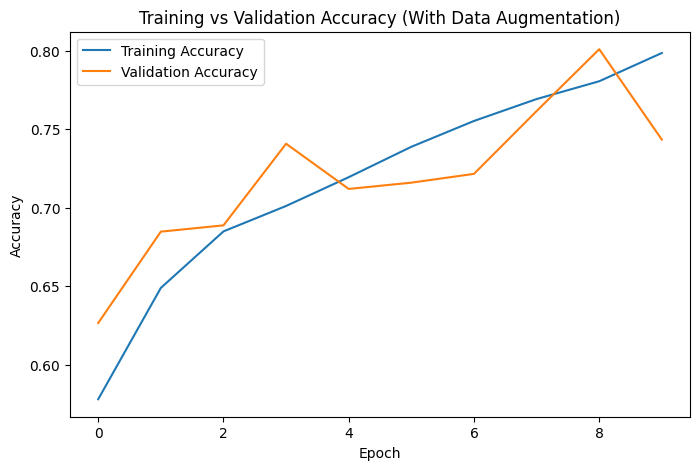

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_with.history['accuracy'], label='Training Accuracy')
plt.plot(history_with.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy (With Data Augmentation)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

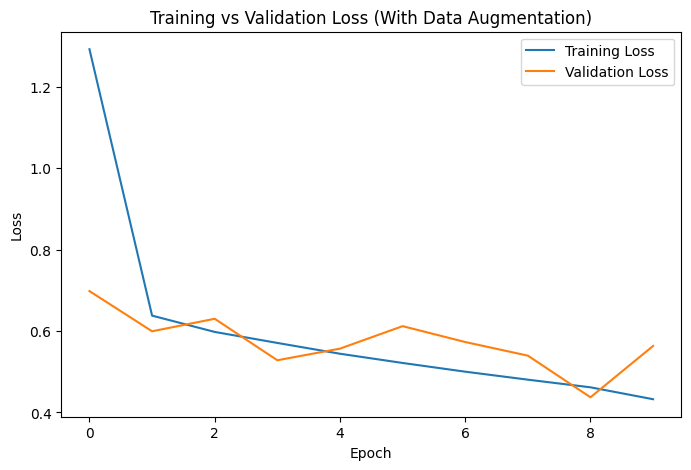

In [33]:
plt.figure(figsize=(8,5))

plt.plot(history_with.history['loss'], label='Training Loss')
plt.plot(history_with.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss (With Data Augmentation)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()